# Image processing

**Duration** ~50 min &nbsp;·&nbsp; **Session** Day 1, Python notebooks

**This notebook covers**

- correcting uneven illumination
- using the gaussian and median filters for denoising
- using morphological operations to clean up a binary image
- separating touching objects with watershed segmentation

**Data**: `data/bbbc020/` field `2h_1` (the nuclei from last notebook) and
`data/misc/rice.png`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os; os.environ["DISPLAY"] = ":1"

from course import DATA, show

## 2. Uneven illumination

Often, images don't show even intensity across the field of view. This can be due to a number of reasons, e.g. uneven illumination or the sample itself. In this section, we will correct uneven illumination in an image of rice grains.

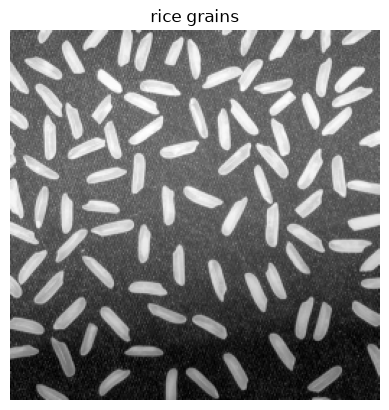

mean intensity, top third   : 131.9
mean intensity, bottom third: 80.8


In [2]:
from skimage.io import imread # for reading png images

rice = imread(DATA / "misc" / "rice.png")

show(rice, title="rice grains")
plt.show()

# Is the lighting even? Compare the top of the image with the bottom.
third_of_the_shape_in_y = rice.shape[0] // 3

print(f"mean intensity, top third   : {rice[:third_of_the_shape_in_y].mean():.1f}")
print(f"mean intensity, bottom third: {rice[-third_of_the_shape_in_y:].mean():.1f}")

The top of the image is much brighter than the bottom, not because the grains
differ, but because the illumination does.

This is a problem for global thresholding.

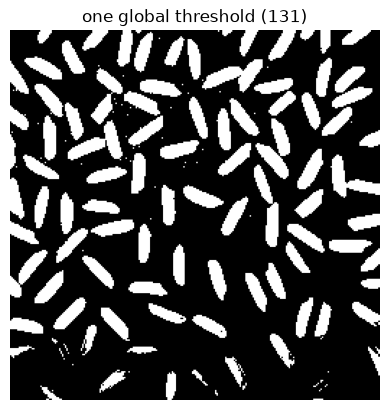

In [3]:
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb

t = threshold_otsu(rice)
rice_binary = rice > t

show(rice_binary, title=f"one global threshold ({t})")
plt.show()

At the bottom of the image, the grains are darker than the threshold, so they are not detected. At the top, the background is brighter than the threshold, so it is detected as foreground.

### Estimating the background and removing it

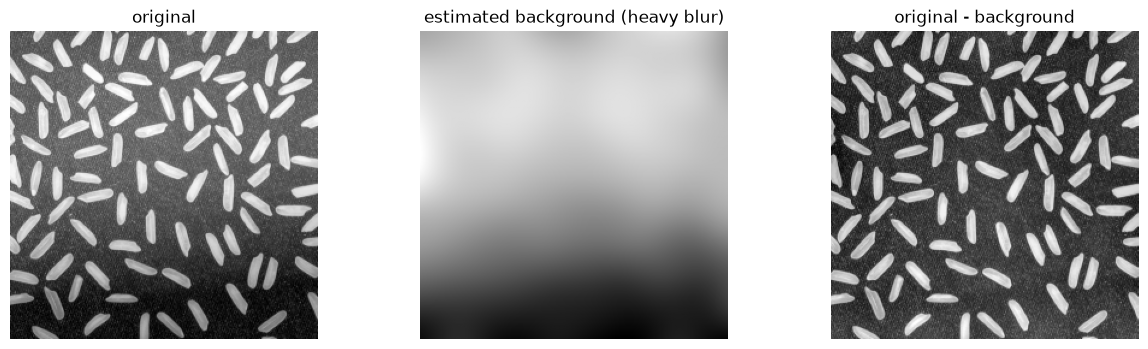

In [4]:
from skimage.filters import gaussian

# Blur the image so heavily that the grains vanish and only the lighting is left.
background = gaussian(rice, sigma=20, preserve_range=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show(rice, title="original", ax=axes[0])
show(background, title="estimated background (heavy blur)", ax=axes[1])
show(rice - background, title="original - background", ax=axes[2])
plt.show()

That is the whole idea of background subtraction: blur away everything of
interest, keep what is left as an estimate of the illumination, and subtract
it.

`skimage` has a purpose-built version of this called a **white top-hat**, which
keeps only features smaller than a given size. It is what Fiji's
`Process ▸ Subtract Background…` (rolling ball) is doing.

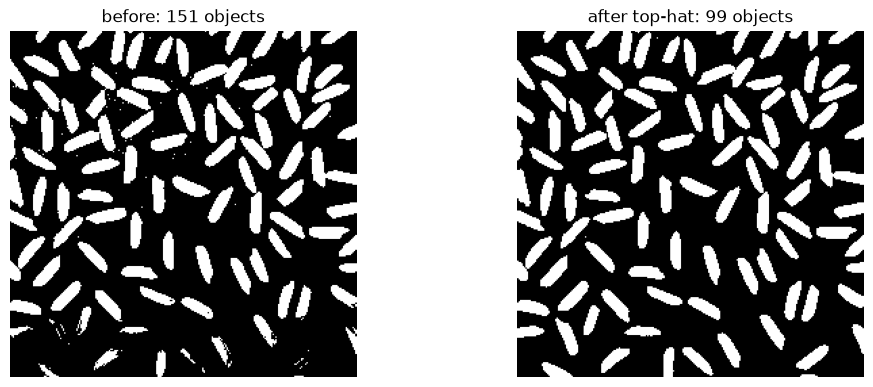

before: 151  after: 99  (expected ~95-100)


In [5]:
from skimage.morphology import white_tophat, disk

# disk(12) must be comfortably LARGER than a grain and smaller than the
# illumination pattern - that is the only tuning this needs.
corrected = white_tophat(rice, disk(12))

t2 = threshold_otsu(corrected)

rice_binary2 = corrected > t2
rice_labels2 = label(rice_binary2)
rice_labels = label(rice_binary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(rice > t, title=f"before: {rice_labels.max()} objects", ax=axes[0])
show(corrected > t2, title=f"after top-hat: {rice_labels2.max()} objects", ax=axes[1])
plt.show()

print("before:", rice_labels.max(), " after:", rice_labels2.max(), " (expected ~95-100)")

This is a good example in which preprocessing the image improves the result of a simple global thresholding.

## 3. Denoising: Gaussian vs median

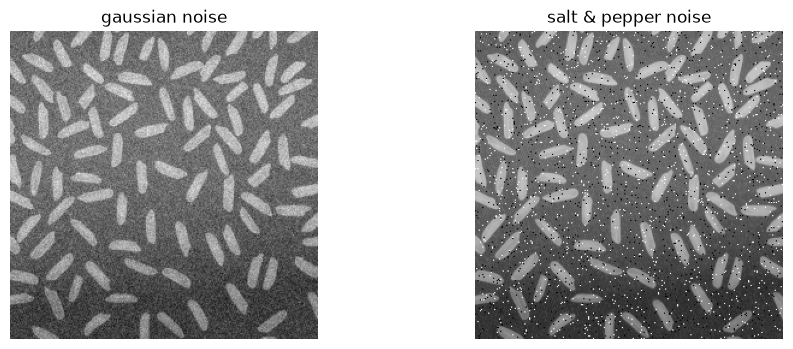

In [6]:
rng = np.random.default_rng(0)

# Two different kinds of noise, to make the point that the fix differs.
grainy = rice.astype(float) + rng.normal(0, 15, rice.shape)

speckled = rice.copy()
spots = rng.random(rice.shape)
speckled[spots < 0.02] = 0      # pepper
speckled[spots > 0.98] = 255    # salt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
show(grainy, title="gaussian noise", ax=axes[0])
show(speckled, title="salt & pepper noise", ax=axes[1])
plt.show()

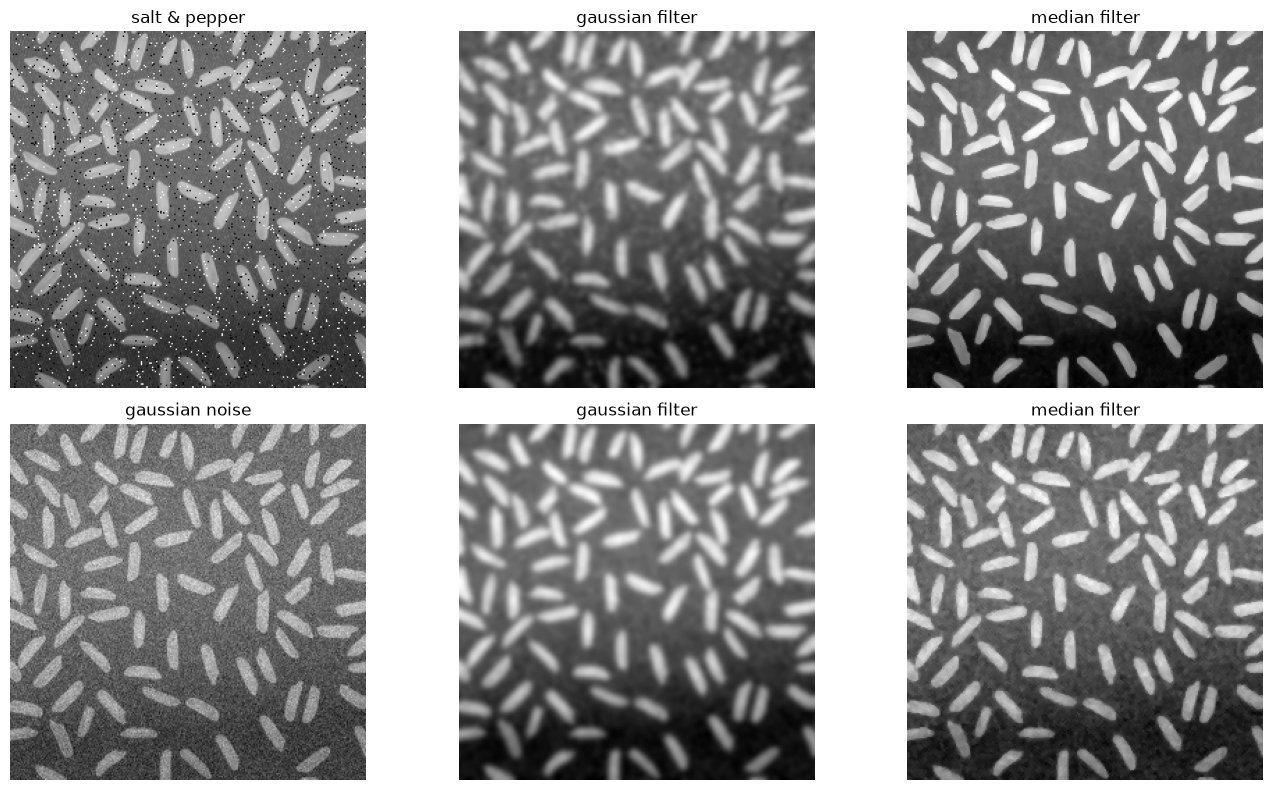

In [7]:
from skimage.filters import median
from skimage.morphology import disk as disk_fp

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

show(speckled, title="salt & pepper", ax=axes[0][0])
show(gaussian(speckled, sigma=2, preserve_range=True), title="gaussian filter", ax=axes[0][1])
show(median(speckled, disk_fp(2)), title="median filter", ax=axes[0][2])

show(grainy, title="gaussian noise", ax=axes[1][0])
show(gaussian(grainy, sigma=2, preserve_range=True), title="gaussian filter", ax=axes[1][1])
show(median(grainy, disk_fp(2)), title="median filter", ax=axes[1][2])

plt.tight_layout()
plt.show()

*Top row*: The Gaussian filter *smears* each salt and pepper dot into a
gray blob: it averages, so one extreme pixel contaminates its whole
neighbourhood. The median filter removes them outright, because the median of a
neighbourhood simply ignores a single wild value.

*Bottom row*: with ordinary grainy noise, both do a reasonable job.

**Rule of thumb**: median for isolated extreme pixels (dead pixels, cosmic rays,
salt and pepper), Gaussian for general graininess.

## 4. Morphology: cleaning up a binary image

The operations so far worked on intensities. **Morphological** operations work on
the *shape* of a binary image. **Important** morphological operations are:

| operation | what it does | use it to |
|---|---|---|
| erosion | shave pixels off every edge | shrink objects, break thin bridges |
| dilation | add pixels to every edge | grow objects, close small gaps |
| opening | erode, then dilate | **remove small specks**, keep big shapes |
| closing | dilate, then erode | **fill small holes**, keep outlines |
| fill holes | fill holes in objects | make objects solid |

Opening and closing are both undoing their own size change: an opening removes specks without shrinking what survives.

<Figure size 640x480 with 0 Axes>

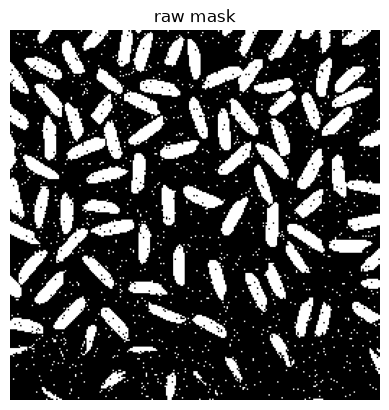

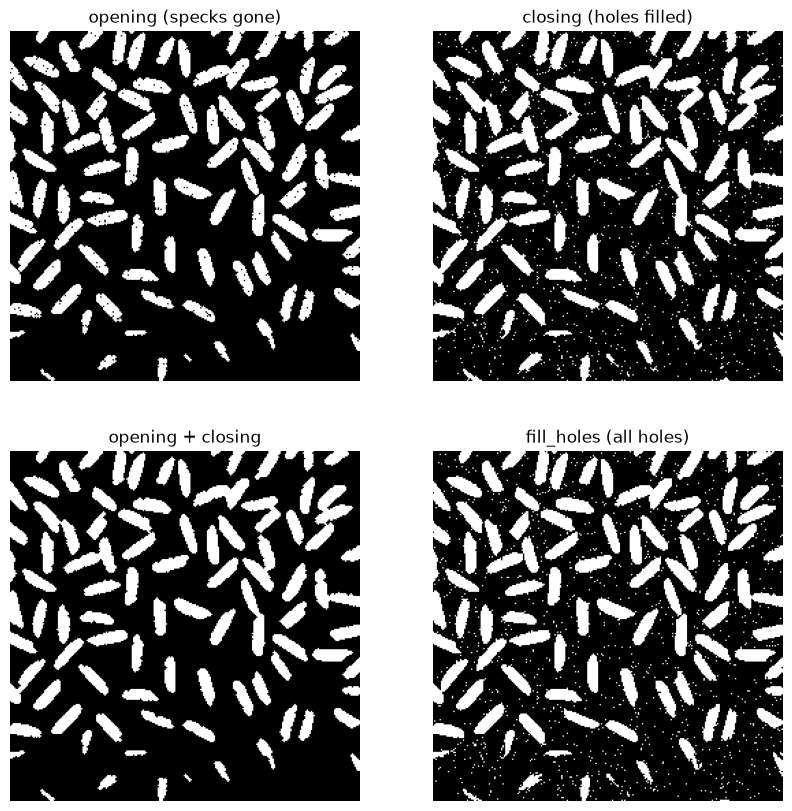

In [8]:
from skimage.morphology import opening, closing
from scipy.ndimage import binary_fill_holes

nuclei = imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")
nuclei = speckled

mask = nuclei > threshold_otsu(nuclei)

plt.figure()
show(mask, title="raw mask")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

show(opening(mask, disk(1)), title="opening (specks gone)", ax=axes[0, 0])
show(closing(mask, disk(1)), title="closing (holes filled)", ax=axes[0, 1])
show(closing(opening(mask, disk(1)), disk(1)), title="opening + closing", ax=axes[1, 0])
show(binary_fill_holes(mask), title="fill_holes (all holes)", ax=axes[1, 1])
plt.show()

## 5. Watershed: a second route from semantic to instance

Let's get back to the nuclei image. We have a semantic segmentation (nuclei vs background), but we want an instance segmentation (each nucleus separately). The watershed algorithm is a way to do that.

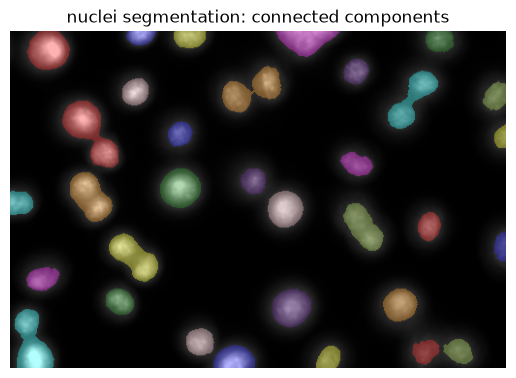

In [9]:
nuclei = imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")
seg = nuclei > threshold_otsu(nuclei)
seg = closing(opening(seg, disk(2)), disk(2))
label_image = label(seg)

show(label2rgb(label_image, image=nuclei, bg_label=0), title="nuclei segmentation: connected components")

### How to separate touching objects? The watershed algorithm

Connected components labels each connected foreground blob. This is simple, but touching objects can receive the same label. Watershed segmentation is a simple method to split touching objects.

Watershed segmentation treats the image as a topographic surface, where pixel values represent height. The algorithm starts from seed points and "floods" the surface, until neighboring regions meet. The result is a partition of the image into instances, where each region corresponds to a seed point. See the scikit-image documentation for a nice illustration and example.

As a topographic surface for watershed segmentation, we will use the distance transform of the mask: Here, pixels within the semantic segmentation mask are replaced by the distance to the closest background pixel (actually, the inverse of the distance will describe the topography). This distance transform can also be used to find starting seeds, namely by determining the local maxima of the distance transform image. To avoid picking up too many seeds, we smooth the distance image before finding the local maxima. We then run watershed on the original distance image.

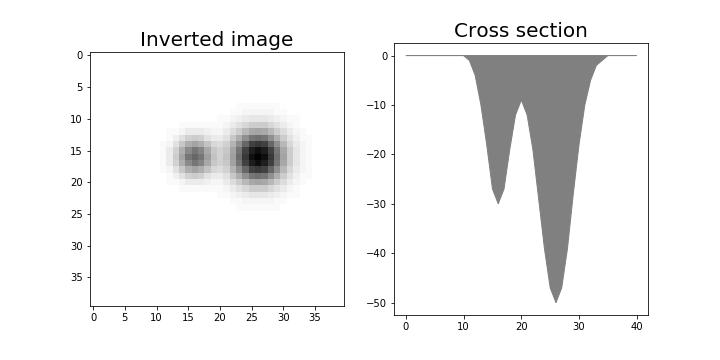

The last notebook turned a semantic segmentation into an instance segmentation
with **connected component labeling**, where pixels that touch belong to the same
object, and showed exactly where that rule breaks: when two nuclei touch they
*are* one connected region, and get one label.

The pixels alone cannot say where to divide them. Their **shape** can. A pair of
touching nuclei is a wide blob with a narrow waist, and that waist is where the
boundary belongs.

The **watershed** exploits this. It treats the binary image as a landscape: imagine each
object as a hill; flood the landscape from the top of each hill, and where two
floods meet is the boundary between the objects.

Two things are needed: a landscape, and a starting point inside each object,
called a **seed**. The landscape comes from the **distance transform**, which replaces
every foreground pixel with its distance to the nearest background pixel. The
middle of an object is far from any edge, so it becomes a peak.

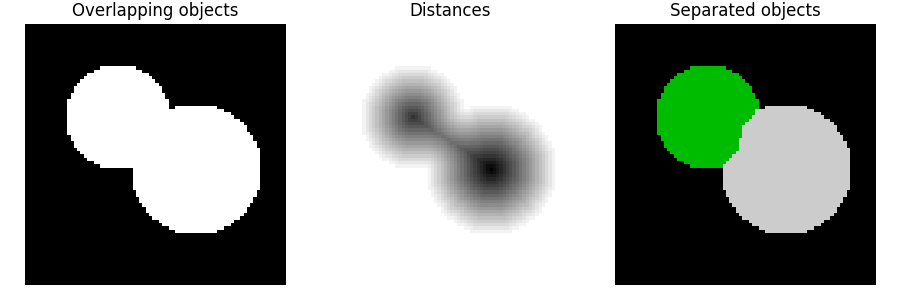

Distance transform of a binary image:

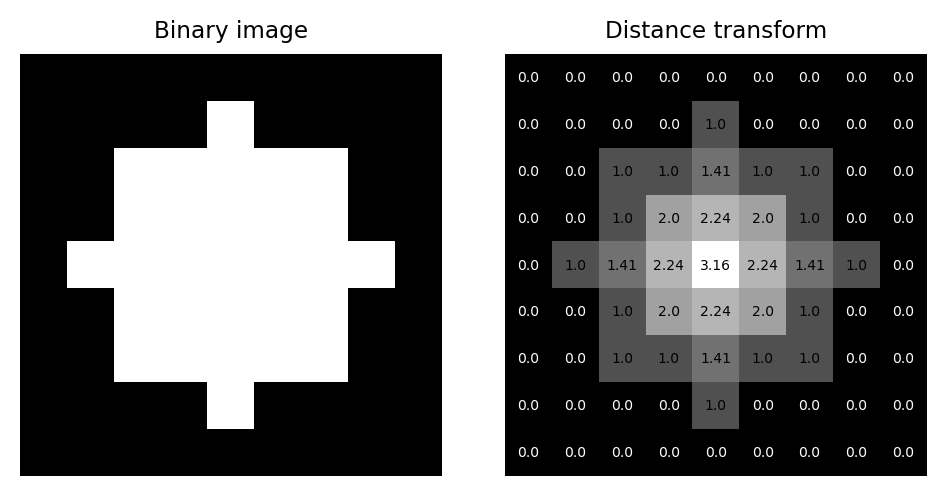


### Separating the touching nuclei with watershed

objects in this crop: 1  (there are really 2 nuclei)


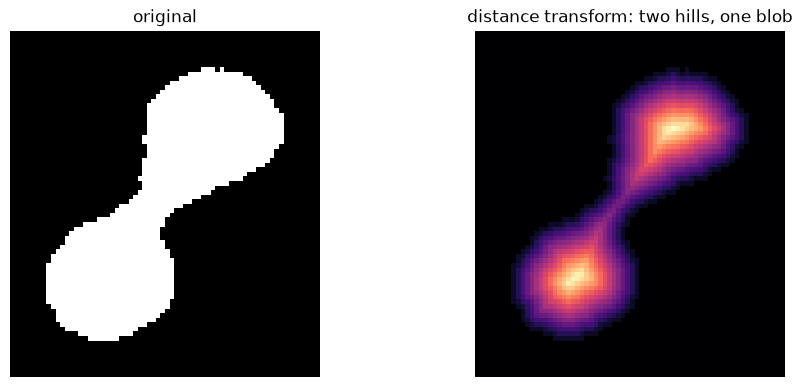

In [10]:
from scipy.ndimage import distance_transform_edt

# Zoom in on a pair that merged.
region = (slice(33, 109), slice(382, 450))
sub_mask = seg[region]
print("objects in this crop:", label(sub_mask).max(), " (there are really 2 nuclei)")

distance = distance_transform_edt(sub_mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
show(seg[region], title="original", ax=axes[0])
show(distance, title="distance transform: two hills, one blob", cmap="magma", ax=axes[1])
plt.show()

### Finding seeds from local maxima

Two hills, so: find the local maxima and use those as seeds. `peak_local_max`
does exactly that when given a distance transform image.

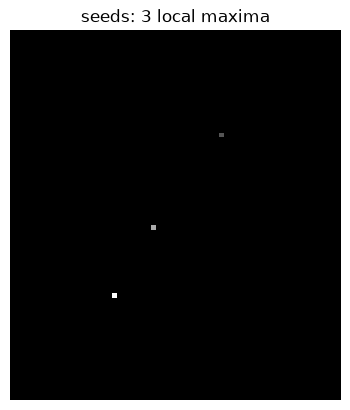

In [21]:
from scipy.ndimage import maximum_filter

def seeds_from_peaks(distance, mask):
    """Return a labeled array of seeds, one for each local maximum in `distance`."""

    # maximum filter: replace pixels with the maximum value in a neighborhood
    seeds = maximum_filter(distance, size=3)
    # Compare the maximum-filtered image with the original distance transform: only keep pixels that are equal to the maximum in their neighborhood.
    seeds = (seeds == distance)  # True where the pixel is a local maximum
    seeds = seeds * mask  # only keep seeds that are in the mask
    seeds = label(seeds)  # label the seeds so that each gets a unique integer

    return seeds

seeds = seeds_from_peaks(distance, sub_mask)

show(seeds, title=f"seeds: {seeds.max()} local maxima")

In [22]:
from skimage.segmentation import watershed

result = watershed(-distance, seeds, mask=sub_mask)

print("seeds found:", seeds.max())
print("objects after watershed:", result.max(), " (we wanted 2)")

seeds found: 3
objects after watershed: 3  (we wanted 2)


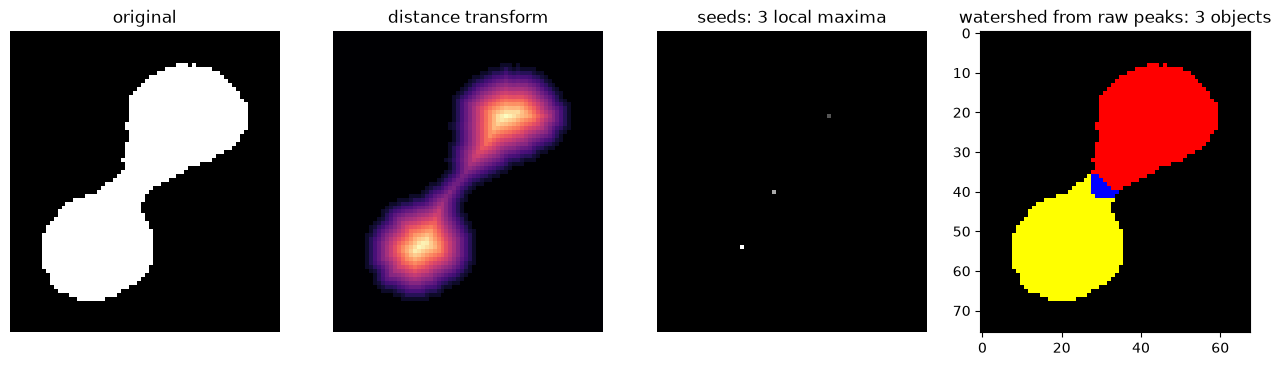

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
show(seg[region], title="original", ax=axes[0])
show(distance, title="distance transform", cmap="magma", ax=axes[1])
show(seeds, title=f"seeds: {seeds.max()} local maxima", ax=axes[2])
axes[3].imshow(label2rgb(result, bg_label=0))#; axes[2].set_axis_off()
axes[3].set_title(f"watershed from raw peaks: {result.max()} objects")
plt.show()

The watershed produced six regions from two nuclei because it received six
seeds.

The problem is the seeds. A distance transform is not smooth: every small
irregularity in the binary image boundary pushes the distance up or down a little, so a
single nucleus has several local maxima a pixel or two apart. `peak_local_max`
reports all of them.

**This is the failure mode to recognise**: when a watershed shatters objects into
fragments, the seeds are almost always the reason.

There are two straightforward ways to fix it.

### Fix 1: keep only the cores, by thresholding the distance

Rather than every local maximum, take the *regions* that lie deep inside the
object: pixels further than `t` from any edge. Each such core becomes one seed.

This gives the parameter a physical meaning. `distance > 5` says *"a seed is a
region whose centre is at least 5 pixels from the nearest boundary"*: that is,
only objects with a radius of about 5 px or more get their own seed.

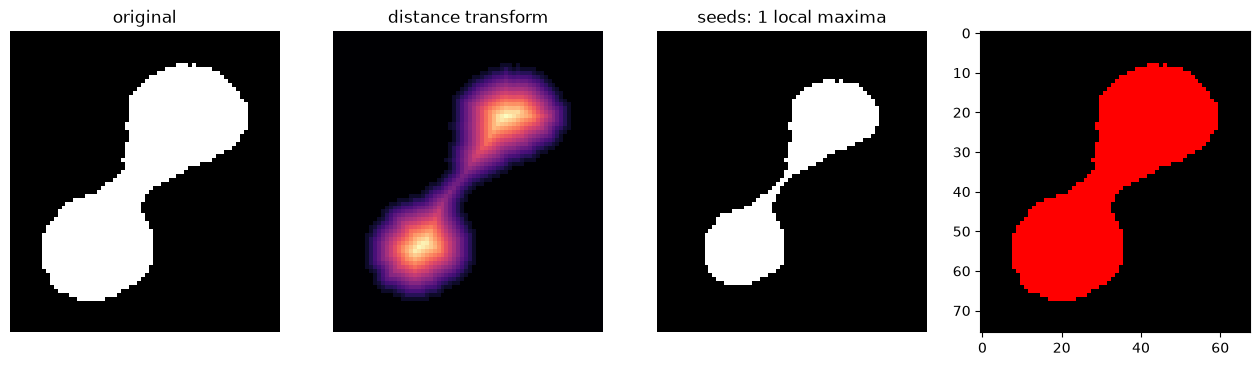

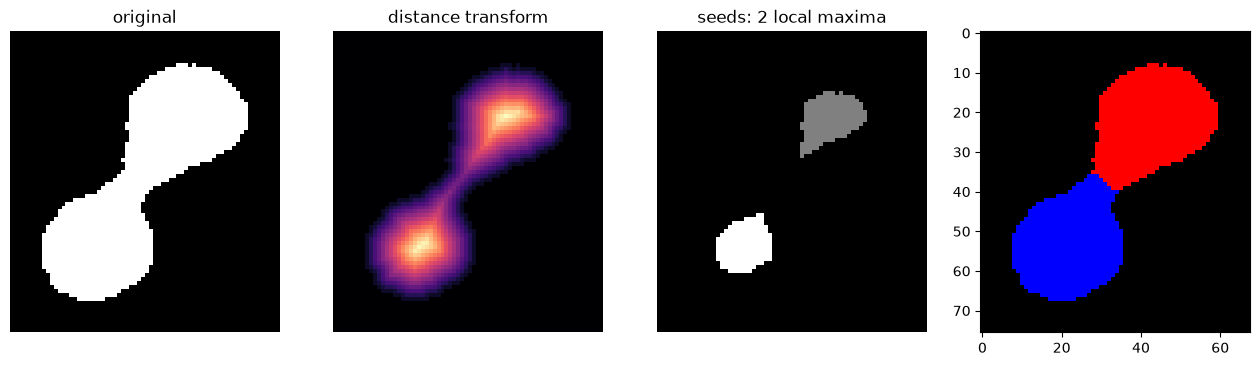

In [14]:
for t in [4, 7]:
    seeds = label(distance > t)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    show(seg[region], title="original", ax=axes[0])
    show(distance, title="distance transform", cmap="magma", ax=axes[1])
    show(seeds, title=f"seeds: {seeds.max()} local maxima", ax=axes[2])
    axes[3].imshow(label2rgb(watershed(-distance, seeds, mask=sub_mask), bg_label=0))
    plt.show()

At `t = 4` the two nuclei still share a single core and stay merged; from `t = 5`
upward the answer settles at two and stays there. A stable range is useful evidence that the count does not depend on one precise
choice of threshold.

### Fix 2: smooth the landscape, then find peaks

The other approach leaves the seed-finding alone and fixes the *landscape*. The
spurious maxima are small bumps, so blur them away before looking for peaks: 
the same trick as smoothing an image before thresholding it, applied to the
distance map instead.

Note that `peak_local_max` is still called with no tuning arguments. All the
control now sits in the Gaussian filter.

In [15]:
from skimage.filters import gaussian as gaussian_filter

for sigma in [1, 2, 3]:
    # smooth the distance transform to remove small local maxima
    smoothed_distance = gaussian_filter(distance, sigma=sigma, preserve_range=True)
    seeds = seeds_from_peaks(smoothed_distance, sub_mask)
    n = watershed(-smoothed_distance, seeds, mask=sub_mask).max()
    print(f"sigma = {sigma}  ->  {seeds.max()} seed(s)  ->  {n} object(s)")

sigma = 1  ->  2 seed(s)  ->  2 object(s)
sigma = 2  ->  2 seed(s)  ->  2 object(s)
sigma = 3  ->  2 seed(s)  ->  2 object(s)


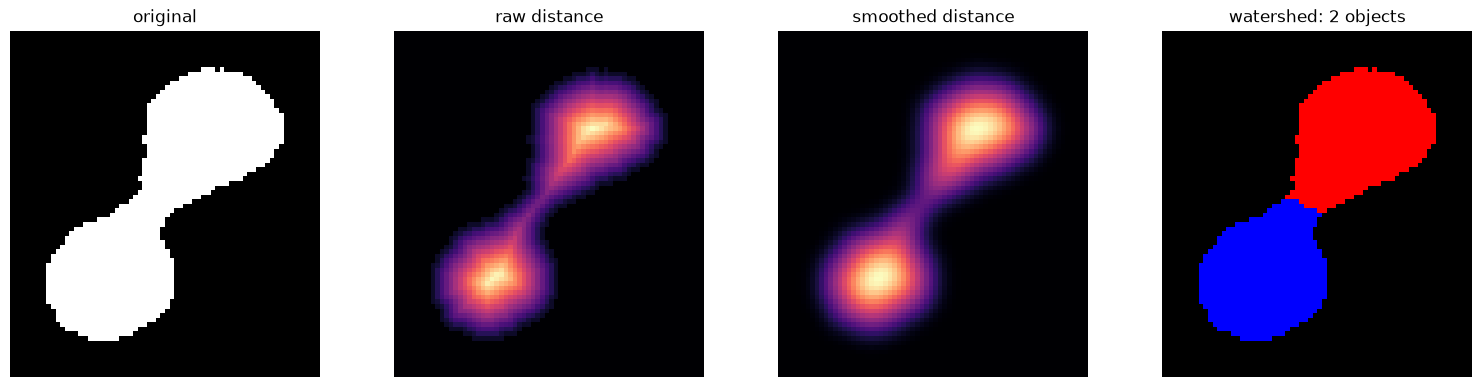

In [16]:
smoothed_distance = gaussian_filter(distance, sigma=2, preserve_range=True)
seeds = seeds_from_peaks(smoothed_distance, sub_mask)
split = watershed(-smoothed_distance, seeds, mask=sub_mask)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(seg[region], title="original", ax=axes[0])
show(distance, title="raw distance", cmap="magma", ax=axes[1])
show(smoothed_distance, title="smoothed distance", cmap="magma", ax=axes[2])
axes[3].imshow(label2rgb(split, bg_label=0)); axes[3].set_axis_off()
axes[3].set_title(f"watershed: {split.max()} objects")
plt.show()

### On the whole image

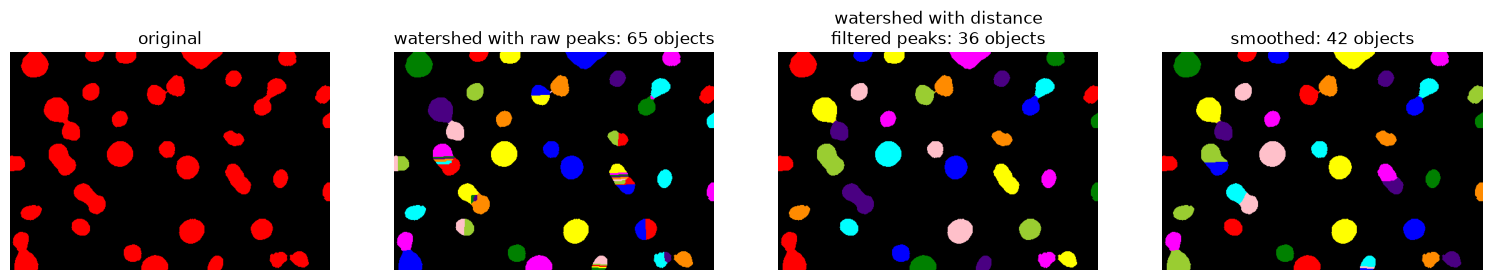

In [17]:
distance_full = distance_transform_edt(seg)

watershed_raw_peaks = watershed(-distance_full, seeds_from_peaks(distance_full, seg), mask=seg)

watershed_dist_peaks = watershed(-distance_full, label(distance_full > 5), mask=seg)

smoothed_full = gaussian_filter(distance_full, sigma=3, preserve_range=True)
watershed_smooth_peaks = watershed(-smoothed_full, seeds_from_peaks(smoothed_full, seg), mask=seg)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(label2rgb(seg, bg_label=0), title="original", ax=axes[0])
show(label2rgb(watershed_raw_peaks, bg_label=0), title=f"watershed with raw peaks: {watershed_raw_peaks.max()} objects", ax=axes[1])
show(label2rgb(watershed_dist_peaks, bg_label=0), title=f"watershed with distance\nfiltered peaks: {watershed_dist_peaks.max()} objects", ax=axes[2])
show(label2rgb(watershed_smooth_peaks, bg_label=0), title=f"smoothed: {watershed_smooth_peaks.max()} objects", ax=axes[3])

## Recap

| problem | symptom | fix |
|---|---|---|
| uneven illumination | one threshold cannot fit everywhere | `white_tophat` |
| noise crossing the threshold | tiny speck "objects" | `gaussian` before thresholding |
| isolated extreme pixels | salt & pepper dots | `median` filter |
| holes inside objects | ring-shaped labels | `closing` / `binary_fill_holes` |
| spurious specks | tiny labels | `opening` |
| objects touching | several objects, one label | `watershed`, carefully seeded |